# PooledAdapter vs Single IbisAdapter - Performance Benchmark

This notebook compares the execution time of running data quality checks using:
1. A single `IbisAdapter` (sequential execution)
2. A `PooledAdapter` wrapping multiple `IbisAdapter` instances (parallel execution)

We test across multiple database access patterns:
- **DuckDB native** — data loaded into DuckDB directly
- **PostgreSQL direct** — native ibis postgres connection
- **DuckDB ATTACH PostgreSQL** — DuckDB attached to Postgres (queries pushed via DuckDB engine)
- **Oracle direct** — native ibis oracle connection
- **DuckDB ATTACH Oracle** — DuckDB attached to Oracle

We also benchmark **MultiSourceAdapter** with pooled adapters for cross-table queries
spanning multiple backends.

In [1]:
import os
import subprocess
import statistics
import time
from pathlib import Path

import ibis
import pandas as pd

from vowl.adapters import IbisAdapter, MultiSourceAdapter, PooledAdapter
from vowl.contracts.contract import Contract

In [2]:
# Paths
TEST_DIR = Path("../tests")
HDB_DIR = TEST_DIR / "hdb_resale"
DATA_FILE = HDB_DIR / "HDBResale.csv"
HDB_CONTRACT_PATH = str(HDB_DIR / "hdb_resale.yaml")

EMPLOYEE_DIR = TEST_DIR / "employee"
EMPLOYEE_PAYROLL_FILE = EMPLOYEE_DIR / "demo_employee_payroll.csv"
EMPLOYEE_LIST_FILE = EMPLOYEE_DIR / "demo_employee_list.csv"
EMPLOYEE_CONTRACT_PATH = str(EMPLOYEE_DIR / "employee_payroll_datacontract.yaml")

# --- Scale factor: repeat the dataset to increase query execution time ---
# Increase this to make individual checks take longer (better for measuring concurrency)
SCALE_FACTOR = 4  # 227k * 4 = ~910k rows

# Load and scale data
df_raw = pd.read_csv(DATA_FILE)
df = pd.concat([df_raw] * SCALE_FACTOR, ignore_index=True)

employee_payroll_raw = pd.read_csv(EMPLOYEE_PAYROLL_FILE)
employee_payroll_df = pd.concat([employee_payroll_raw] * SCALE_FACTOR * 100, ignore_index=True)  # 3 * 400 = 1200 rows

employee_list_raw = pd.read_csv(EMPLOYEE_LIST_FILE)
employee_list_df = pd.concat([employee_list_raw] * SCALE_FACTOR * 100, ignore_index=True)  # 2 * 400 = 800 rows

print(f"Scale factor: {SCALE_FACTOR}x")
print(f"HDB Dataset: {len(df):,} rows x {len(df.columns)} columns (original: {len(df_raw):,})")
print(f"Employee Payroll: {len(employee_payroll_df):,} rows (original: {len(employee_payroll_raw):,})")
print(f"Employee List: {len(employee_list_df):,} rows (original: {len(employee_list_raw):,})")

# Load HDB contract and get check references
hdb_contract = Contract.load(HDB_CONTRACT_PATH)
hdb_refs_by_schema = hdb_contract.get_check_references_by_schema()
hdb_check_refs = [ref for refs in hdb_refs_by_schema.values() for ref in refs]
print(f"\nHDB checks: {len(hdb_check_refs)}")
for ref in hdb_check_refs:
    print(f"  - {ref.get_check_name()}")

# Load Employee contract (has cross-table checks)
emp_contract = Contract.load(EMPLOYEE_CONTRACT_PATH)
emp_refs_by_schema = emp_contract.get_check_references_by_schema()
emp_check_refs = [ref for refs in emp_refs_by_schema.values() for ref in refs]
print(f"\nEmployee checks: {len(emp_check_refs)}")
for ref in emp_check_refs:
    print(f"  - {ref.get_check_name()}")

Scale factor: 4x
HDB Dataset: 910,940 rows x 11 columns (original: 227,735)
Employee Payroll: 1,200 rows (original: 3)
Employee List: 800 rows (original: 2)

HDB checks: 63
  - month_column_exists_check
  - month_logical_type_check
  - month_logical_type_options_pattern_check
  - month_logical_type_options_format_check
  - month_logical_type_options_minLength_check
  - month_logical_type_options_maxLength_check
  - month_required_check
  - town_column_exists_check
  - town_logical_type_check
  - town_required_check
  - flat_type_column_exists_check
  - flat_type_logical_type_check
  - flat_type_required_check
  - block_column_exists_check
  - block_logical_type_check
  - block_logical_type_options_minLength_check
  - block_logical_type_options_maxLength_check
  - block_logical_type_options_pattern_check
  - block_required_check
  - street_name_column_exists_check
  - street_name_logical_type_check
  - street_name_logical_type_options_minLength_check
  - street_name_logical_type_options

## Docker & Testcontainers Setup

In [3]:
def docker_available() -> bool:
    try:
        subprocess.run(["docker", "info"], capture_output=True, check=True, timeout=5)
        return True
    except (subprocess.CalledProcessError, subprocess.TimeoutExpired, FileNotFoundError):
        return False

def configure_docker_env():
    docker_sock = Path.home() / ".docker" / "run" / "docker.sock"
    if docker_sock.exists() and "DOCKER_HOST" not in os.environ:
        os.environ["DOCKER_HOST"] = f"unix://{docker_sock}"
    if "TESTCONTAINERS_RYUK_DISABLED" not in os.environ:
        os.environ["TESTCONTAINERS_RYUK_DISABLED"] = "true"

HAS_DOCKER = docker_available()
if HAS_DOCKER:
    configure_docker_env()
    print("Docker is available - all benchmarks will run")
else:
    raise RuntimeError("Docker is required for this benchmark notebook")

Docker is available - all benchmarks will run


## Benchmark Harness

In [4]:
N_ITERATIONS = 5
CONCURRENCY_LEVELS = [1, 2, 4, 8]


def benchmark_adapter(adapter, check_refs, label: str, n_iterations: int = N_ITERATIONS) -> list[float]:
    """Run checks on an adapter multiple times and return elapsed times."""
    times = []
    for i in range(n_iterations):
        start = time.perf_counter()
        results = adapter.run_checks(check_refs)
        elapsed = time.perf_counter() - start
        times.append(elapsed)
        n_passed = sum(1 for r in results if r.status == "PASSED")
        n_error = sum(1 for r in results if r.status == "ERROR")
        print(f"  [{label}] Iter {i+1}: {elapsed:.4f}s "
              f"({len(results)} checks, {n_passed} passed, {n_error} errors)")
    return times


def benchmark_multi_source(multi_adapter, refs_by_schema, label: str, n_iterations: int = N_ITERATIONS) -> list[float]:
    """Run checks on a MultiSourceAdapter multiple times."""
    times = []
    for i in range(n_iterations):
        start = time.perf_counter()
        results = multi_adapter.run_checks(refs_by_schema)
        elapsed = time.perf_counter() - start
        times.append(elapsed)
        n_passed = sum(1 for r in results if r.status == "PASSED")
        n_error = sum(1 for r in results if r.status == "ERROR")
        print(f"  [{label}] Iter {i+1}: {elapsed:.4f}s "
              f"({len(results)} checks, {n_passed} passed, {n_error} errors)")
    return times


def run_benchmark_suite(
    backend_name: str,
    single_adapter,
    pooled_factory,
    check_refs,
) -> dict[str, list[float]]:
    """Run full benchmark for a backend: single + pooled at various concurrency levels."""
    results = {}

    label = f"{backend_name} single"
    print(f"\n{'='*60}")
    print(f"  {backend_name} - Single IbisAdapter (sequential)")
    print(f"{'='*60}")
    results[label] = benchmark_adapter(single_adapter, check_refs, label)

    for c in CONCURRENCY_LEVELS:
        label = f"{backend_name} pooled(c={c})"
        print(f"\n{'='*60}")
        print(f"  {backend_name} - PooledAdapter (concurrency={c})")
        print(f"{'='*60}")
        pooled = PooledAdapter(factory=pooled_factory, max_concurrency=c)
        results[label] = benchmark_adapter(pooled, check_refs, label)
        pooled.cleanup()

    return results

## Start Database Containers

In [5]:
from testcontainers.postgres import PostgresContainer

# PostgreSQL: increase max_connections to support high concurrency benchmarks
# Default is 100 which is fine, but we set it explicitly to be safe
print("Starting PostgreSQL container...")
pg_container = PostgresContainer(
    "postgres:15-alpine",
    # Increase shared_buffers and max_connections for pooled benchmarks
)
pg_container.with_command("postgres -c max_connections=200 -c shared_buffers=256MB")
pg_container.start()

pg_kwargs = {
    "host": pg_container.get_container_host_ip(),
    "port": int(pg_container.get_exposed_port(5432)),
    "user": pg_container.username,
    "password": pg_container.password,
    "database": pg_container.dbname,
}
print(f"PostgreSQL running at {pg_kwargs['host']}:{pg_kwargs['port']}")

# Verify max_connections
pg_verify_con = ibis.postgres.connect(**pg_kwargs)
max_conn = pg_verify_con.raw_sql("SHOW max_connections").fetchone()[0]
print(f"PostgreSQL max_connections: {max_conn}")
pg_verify_con.disconnect()

# Build connection string for DuckDB ATTACH
pg_conn_str = f"postgresql://{pg_kwargs['user']}:{pg_kwargs['password']}@{pg_kwargs['host']}:{pg_kwargs['port']}/{pg_kwargs['database']}"

Starting PostgreSQL container...
PostgreSQL running at localhost:52599
PostgreSQL max_connections: 200


In [6]:
oracle_kwargs = None
oracle_container = None

try:
    from testcontainers.oracle import OracleDbContainer

    print("Starting Oracle container (this may take a minute)...")
    oracle_container = OracleDbContainer(
        image="gvenzl/oracle-free:slim",
        oracle_password="OraclePass1",
        username="testuser",
        password="testpass",
        dbname="FREEPDB1",
    )
    # Oracle Free defaults to processes=100, sessions=150 which may bottleneck
    # high concurrency. We increase via init script after startup.
    oracle_container.start()

    oracle_kwargs = {
        "host": oracle_container.get_container_host_ip(),
        "port": int(oracle_container.get_exposed_port(1521)),
        "user": oracle_container.username,
        "password": oracle_container.password,
        "service_name": "FREEPDB1",
    }
    print(f"Oracle running at {oracle_kwargs['host']}:{oracle_kwargs['port']}")

    # Verify and increase Oracle session limits if needed
    oracle_admin_con = ibis.oracle.connect(
        host=oracle_kwargs["host"],
        port=oracle_kwargs["port"],
        user="system",
        password="OraclePass1",
        service_name="FREEPDB1",
    )
    sessions = oracle_admin_con.raw_sql(
        "SELECT value FROM v$parameter WHERE name = 'sessions'"
    ).fetchone()[0]
    processes = oracle_admin_con.raw_sql(
        "SELECT value FROM v$parameter WHERE name = 'processes'"
    ).fetchone()[0]
    print(f"Oracle processes: {processes}, sessions: {sessions}")

    # Increase if too low for our concurrency sweep (max c=12 + overhead)
    if int(processes) < 50:
        print("  Increasing Oracle processes/sessions for concurrency benchmarks...")
        oracle_admin_con.raw_sql("ALTER SYSTEM SET processes=200 SCOPE=SPFILE")
        oracle_admin_con.raw_sql("ALTER SYSTEM SET sessions=300 SCOPE=SPFILE")
        print("  NOTE: Changes require DB restart (SPFILE). May not take effect in this run.")
    oracle_admin_con.disconnect()

except Exception as e:
    print(f"Oracle not available ({e}) - Oracle benchmarks will be skipped")

Starting Oracle container (this may take a minute)...
Oracle running at localhost:52602
Oracle processes: 200, sessions: 322


## Load Data into Databases

In [7]:
# --- DuckDB native (persistent file for pooled connections) ---
DUCKDB_PATH = "/tmp/benchmark_hdb.duckdb"
setup_con = ibis.duckdb.connect(DUCKDB_PATH)
setup_con.raw_sql("DROP TABLE IF EXISTS hdb_resale_prices")
setup_con.create_table("hdb_resale_prices", df)
setup_con.disconnect()
print(f"DuckDB native: loaded {len(df):,} rows")

# --- PostgreSQL ---
pg_con = ibis.postgres.connect(**pg_kwargs)
pg_con.raw_sql("DROP TABLE IF EXISTS hdb_resale_prices")
pg_con.raw_sql("""
    CREATE TABLE hdb_resale_prices (
        month TEXT, town TEXT, flat_type TEXT, block TEXT,
        street_name TEXT, storey_range TEXT, floor_area_sqm NUMERIC,
        flat_model TEXT, lease_commence_date NUMERIC,
        remaining_lease TEXT, resale_price NUMERIC
    )
""")
pg_df = df.copy()
for col in ("floor_area_sqm", "lease_commence_date", "resale_price"):
    pg_df[col] = pd.to_numeric(pg_df[col], errors="coerce")

BATCH_SIZE = 10000
for start in range(0, len(pg_df), BATCH_SIZE):
    batch = pg_df.iloc[start:start + BATCH_SIZE]
    pg_con.insert("hdb_resale_prices", batch)
    if start % 100000 == 0:
        print(f"  PostgreSQL: {start:,}/{len(pg_df):,} rows...", end="\r")
print(f"PostgreSQL: loaded {len(pg_df):,} rows              ")

# Also load employee tables into PostgreSQL for multi-source tests
pg_con.raw_sql("DROP TABLE IF EXISTS demo_employee_payroll")
pg_con.raw_sql("""
    CREATE TABLE demo_employee_payroll (
        employee_id TEXT, payroll_id TEXT, month TEXT,
        payroll_start_dt TEXT, payroll_end_dt TEXT,
        total_amt NUMERIC, employer_cpf_amt NUMERIC,
        total_amt_employee NUMERIC, employee_cpf_amt NUMERIC,
        employee_gross_amt NUMERIC, phone_number TEXT
    )
""")
payroll_insert = employee_payroll_df.copy().fillna("")
for col in ["total_amt", "employer_cpf_amt", "total_amt_employee", "employee_cpf_amt", "employee_gross_amt"]:
    payroll_insert[col] = pd.to_numeric(payroll_insert[col], errors="coerce")
pg_con.insert("demo_employee_payroll", payroll_insert)

pg_con.raw_sql("DROP TABLE IF EXISTS demo_employee_list")
list_cols = ", ".join(f'"{c}" TEXT' for c in employee_list_df.columns)
pg_con.raw_sql(f"CREATE TABLE demo_employee_list ({list_cols})")
pg_con.insert("demo_employee_list", employee_list_df.fillna("").astype(str))
print(f"PostgreSQL: loaded employee tables (payroll={len(employee_payroll_df):,}, list={len(employee_list_df):,})")
pg_con.disconnect()

# --- Oracle (same data volume as PostgreSQL for fair comparison) ---
if oracle_kwargs:
    oracle_con = ibis.oracle.connect(**oracle_kwargs)
    try:
        oracle_con.raw_sql('DROP TABLE "hdb_resale_prices"')
    except Exception:
        pass
    oracle_con.raw_sql("""
        CREATE TABLE "hdb_resale_prices" (
            "month" VARCHAR2(7), "town" VARCHAR2(50), "flat_type" VARCHAR2(20),
            "block" VARCHAR2(10), "street_name" VARCHAR2(100),
            "storey_range" VARCHAR2(20), "floor_area_sqm" NUMBER(10),
            "flat_model" VARCHAR2(50), "lease_commence_date" NUMBER(10),
            "remaining_lease" VARCHAR2(50), "resale_price" NUMBER(12)
        )
    """)
    oracle_df = df.copy()
    for col in ("floor_area_sqm", "lease_commence_date", "resale_price"):
        oracle_df[col] = pd.to_numeric(oracle_df[col], errors="coerce").fillna(0).astype(int)
    for col in ("month", "town", "flat_type", "block", "street_name", "storey_range", "flat_model", "remaining_lease"):
        oracle_df[col] = oracle_df[col].astype(str)

    # Use raw SQL batch inserts (ibis con.insert doesn't handle Oracle quoted table names well)
    def _oracle_batch_insert(con, table_name, dataframe, batch_size=1000):
        """Insert via executemany-style raw SQL for Oracle quoted tables."""
        cols = ", ".join(f'"{c}"' for c in dataframe.columns)
        for start in range(0, len(dataframe), batch_size):
            batch = dataframe.iloc[start:start + batch_size]
            for _, row in batch.iterrows():
                vals = []
                for v in row.values:
                    if pd.isna(v):
                        vals.append("NULL")
                    elif isinstance(v, (int, float)):
                        vals.append(str(int(v)))
                    else:
                        vals.append(f"'{str(v).replace(chr(39), chr(39)*2)}'")
                con.raw_sql(f'INSERT INTO {table_name} ({cols}) VALUES ({", ".join(vals)})')
            con.raw_sql("COMMIT")
            if start % 50000 == 0:
                print(f"  Oracle: {start + len(batch):,}/{len(dataframe):,} rows...", end="\r")

    _oracle_batch_insert(oracle_con, '"hdb_resale_prices"', oracle_df)
    print(f"Oracle: loaded {len(oracle_df):,} rows              ")

    # Verify row counts match
    pg_verify = ibis.postgres.connect(**pg_kwargs)
    pg_count = pg_verify.raw_sql("SELECT COUNT(*) FROM hdb_resale_prices").fetchone()[0]
    oracle_count = oracle_con.raw_sql('SELECT COUNT(*) FROM "hdb_resale_prices"').fetchone()[0]
    pg_verify.disconnect()
    oracle_con.disconnect()
    print(f"\nRow count verification:")
    print(f"  PostgreSQL: {pg_count:,}")
    print(f"  Oracle:     {oracle_count:,}")
    print(f"  Match: {pg_count == oracle_count}")

DuckDB native: loaded 910,940 rows
PostgreSQL: loaded 910,940 rows              
PostgreSQL: loaded employee tables (payroll=1,200, list=800)
Oracle: loaded 910,940 rows              

Row count verification:
  PostgreSQL: 910,940
  Oracle:     910,940
  Match: True


## Benchmark: DuckDB Native (In-Process)

In [8]:
duckdb_single = IbisAdapter(con=ibis.duckdb.connect(DUCKDB_PATH))

def duckdb_factory():
    return IbisAdapter(con=ibis.duckdb.connect(DUCKDB_PATH))

duckdb_results = run_benchmark_suite("DuckDB native", duckdb_single, duckdb_factory, hdb_check_refs)


  DuckDB native - Single IbisAdapter (sequential)
  [DuckDB native single] Iter 1: 2.2545s (63 checks, 60 passed, 0 errors)
  [DuckDB native single] Iter 2: 1.9307s (63 checks, 60 passed, 0 errors)
  [DuckDB native single] Iter 3: 1.9397s (63 checks, 60 passed, 0 errors)
  [DuckDB native single] Iter 4: 1.9393s (63 checks, 60 passed, 0 errors)
  [DuckDB native single] Iter 5: 1.9936s (63 checks, 60 passed, 0 errors)

  DuckDB native - PooledAdapter (concurrency=1)
  [DuckDB native pooled(c=1)] Iter 1: 1.9536s (63 checks, 60 passed, 0 errors)
  [DuckDB native pooled(c=1)] Iter 2: 2.0137s (63 checks, 60 passed, 0 errors)
  [DuckDB native pooled(c=1)] Iter 3: 1.9403s (63 checks, 60 passed, 0 errors)
  [DuckDB native pooled(c=1)] Iter 4: 1.9607s (63 checks, 60 passed, 0 errors)
  [DuckDB native pooled(c=1)] Iter 5: 1.9463s (63 checks, 60 passed, 0 errors)

  DuckDB native - PooledAdapter (concurrency=2)
  [DuckDB native pooled(c=2)] Iter 1: 1.9173s (63 checks, 60 passed, 0 errors)
  [Duck

## Benchmark: PostgreSQL Direct (ibis.postgres.connect)

In [9]:
pg_single = IbisAdapter(con=ibis.postgres.connect(**pg_kwargs))

def pg_factory():
    return IbisAdapter(con=ibis.postgres.connect(**pg_kwargs))

pg_results = run_benchmark_suite("PG direct", pg_single, pg_factory, hdb_check_refs)


  PG direct - Single IbisAdapter (sequential)
  [PG direct single] Iter 1: 4.5636s (63 checks, 60 passed, 0 errors)
  [PG direct single] Iter 2: 4.4987s (63 checks, 60 passed, 0 errors)
  [PG direct single] Iter 3: 4.4121s (63 checks, 60 passed, 0 errors)
  [PG direct single] Iter 4: 4.4383s (63 checks, 60 passed, 0 errors)
  [PG direct single] Iter 5: 4.7033s (63 checks, 60 passed, 0 errors)

  PG direct - PooledAdapter (concurrency=1)
  [PG direct pooled(c=1)] Iter 1: 4.5016s (63 checks, 60 passed, 0 errors)
  [PG direct pooled(c=1)] Iter 2: 4.4625s (63 checks, 60 passed, 0 errors)
  [PG direct pooled(c=1)] Iter 3: 4.4805s (63 checks, 60 passed, 0 errors)
  [PG direct pooled(c=1)] Iter 4: 4.4546s (63 checks, 60 passed, 0 errors)
  [PG direct pooled(c=1)] Iter 5: 4.4636s (63 checks, 60 passed, 0 errors)

  PG direct - PooledAdapter (concurrency=2)
  [PG direct pooled(c=2)] Iter 1: 2.5415s (63 checks, 60 passed, 0 errors)
  [PG direct pooled(c=2)] Iter 2: 2.5214s (63 checks, 60 passed

## Benchmark: DuckDB ATTACH PostgreSQL

DuckDB connects to PostgreSQL via `ATTACH` and queries tables through the DuckDB engine.
This uses DuckDB's query optimizer while reading data from PostgreSQL.

In [10]:
def make_duckdb_attach_pg():
    """Create a DuckDB connection attached to PostgreSQL."""
    con = ibis.duckdb.connect()
    con.raw_sql("INSTALL postgres; LOAD postgres;")
    con.raw_sql(f"ATTACH '{pg_conn_str}' AS pg (TYPE postgres, READ_ONLY)")
    con.raw_sql("USE pg")
    return IbisAdapter(con)

duckdb_pg_single = make_duckdb_attach_pg()

duckdb_pg_results = run_benchmark_suite(
    "DuckDB ATTACH PG", duckdb_pg_single, make_duckdb_attach_pg, hdb_check_refs
)


  DuckDB ATTACH PG - Single IbisAdapter (sequential)
  [DuckDB ATTACH PG single] Iter 1: 8.7306s (63 checks, 59 passed, 0 errors)
  [DuckDB ATTACH PG single] Iter 2: 8.9765s (63 checks, 59 passed, 0 errors)
  [DuckDB ATTACH PG single] Iter 3: 7.6293s (63 checks, 59 passed, 0 errors)
  [DuckDB ATTACH PG single] Iter 4: 7.3737s (63 checks, 59 passed, 0 errors)
  [DuckDB ATTACH PG single] Iter 5: 7.0625s (63 checks, 59 passed, 0 errors)

  DuckDB ATTACH PG - PooledAdapter (concurrency=1)
  [DuckDB ATTACH PG pooled(c=1)] Iter 1: 7.1368s (63 checks, 59 passed, 0 errors)
  [DuckDB ATTACH PG pooled(c=1)] Iter 2: 7.3274s (63 checks, 59 passed, 0 errors)
  [DuckDB ATTACH PG pooled(c=1)] Iter 3: 7.1862s (63 checks, 59 passed, 0 errors)
  [DuckDB ATTACH PG pooled(c=1)] Iter 4: 7.6027s (63 checks, 59 passed, 0 errors)
  [DuckDB ATTACH PG pooled(c=1)] Iter 5: 8.3151s (63 checks, 59 passed, 0 errors)

  DuckDB ATTACH PG - PooledAdapter (concurrency=2)
  [DuckDB ATTACH PG pooled(c=2)] Iter 1: 5.5145

## Benchmark: Oracle Direct (ibis.oracle.connect)

In [11]:
oracle_results = {}

if oracle_kwargs:
    oracle_single = IbisAdapter(con=ibis.oracle.connect(**oracle_kwargs))

    def oracle_factory():
        return IbisAdapter(con=ibis.oracle.connect(**oracle_kwargs))

    oracle_results = run_benchmark_suite("Oracle direct", oracle_single, oracle_factory, hdb_check_refs)
else:
    print("Skipping Oracle direct benchmark")


  Oracle direct - Single IbisAdapter (sequential)
  [Oracle direct single] Iter 1: 10.5073s (63 checks, 60 passed, 0 errors)
  [Oracle direct single] Iter 2: 10.0543s (63 checks, 60 passed, 0 errors)
  [Oracle direct single] Iter 3: 10.0209s (63 checks, 60 passed, 0 errors)
  [Oracle direct single] Iter 4: 9.8289s (63 checks, 60 passed, 0 errors)
  [Oracle direct single] Iter 5: 9.8109s (63 checks, 60 passed, 0 errors)

  Oracle direct - PooledAdapter (concurrency=1)
  [Oracle direct pooled(c=1)] Iter 1: 9.8985s (63 checks, 60 passed, 0 errors)
  [Oracle direct pooled(c=1)] Iter 2: 9.8177s (63 checks, 60 passed, 0 errors)
  [Oracle direct pooled(c=1)] Iter 3: 9.8194s (63 checks, 60 passed, 0 errors)
  [Oracle direct pooled(c=1)] Iter 4: 9.9057s (63 checks, 60 passed, 0 errors)
  [Oracle direct pooled(c=1)] Iter 5: 9.8409s (63 checks, 60 passed, 0 errors)

  Oracle direct - PooledAdapter (concurrency=2)
  [Oracle direct pooled(c=2)] Iter 1: 5.1874s (63 checks, 60 passed, 0 errors)
  [O

## Benchmark: DuckDB ATTACH Oracle

DuckDB doesn't have a native Oracle scanner, but we can test this pattern if available.
If the Oracle scanner extension is not installed, this section is skipped.

In [12]:
duckdb_oracle_results = {}

if oracle_kwargs:
    try:
        def make_duckdb_attach_oracle():
            """Create a DuckDB connection attached to Oracle (if scanner available)."""
            con = ibis.duckdb.connect()
            con.raw_sql("INSTALL oracle; LOAD oracle;")
            oracle_dsn = f"{oracle_kwargs['host']}:{oracle_kwargs['port']}/{oracle_kwargs['service_name']}"
            con.raw_sql(
                f"ATTACH 'host={oracle_kwargs['host']} port={oracle_kwargs['port']} "
                f"user={oracle_kwargs['user']} password={oracle_kwargs['password']} "
                f"service_name={oracle_kwargs['service_name']}' AS ora (TYPE oracle, READ_ONLY)"
            )
            con.raw_sql("USE ora")
            return IbisAdapter(con)

        duckdb_oracle_single = make_duckdb_attach_oracle()
        duckdb_oracle_results = run_benchmark_suite(
            "DuckDB ATTACH Oracle", duckdb_oracle_single, make_duckdb_attach_oracle, hdb_check_refs
        )
    except Exception as e:
        print(f"DuckDB ATTACH Oracle not available: {e}")
        print("(DuckDB Oracle scanner extension may not be installed)")
else:
    print("Skipping DuckDB ATTACH Oracle benchmark (Oracle container not available)")

DuckDB ATTACH Oracle not available: HTTP Error: Failed to download extension "oracle" at URL "http://extensions.duckdb.org/v1.5.1/osx_arm64/oracle.duckdb_extension.gz" (HTTP 404)

Candidate extensions: "autocomplete", "ducklake", "odbc", "azure", "excel"
For more info, visit https://duckdb.org/docs/stable/extensions/troubleshooting?version=v1.5.1&platform=osx_arm64&extension=oracle
(DuckDB Oracle scanner extension may not be installed)


## Benchmark: MultiSourceAdapter (Cross-Table, Multi-Backend)

Tests the employee contract which has cross-table JOIN checks (`employee_id_exists_in_master_list`,
`phone_number_exists_in_master_list`). We compare:

1. **DuckDB native** — both tables in DuckDB
2. **PostgreSQL direct** — both tables on PostgreSQL
3. **DuckDB ATTACH PG** — both tables accessed via DuckDB attached to PostgreSQL
4. **Cross-backend** — payroll on PostgreSQL, list on DuckDB (Mode 2 materialization)

Each configuration tested with single adapters and pooled adapters.

In [13]:
multi_results = {}

# --- DuckDB native, single adapters ---
print("="*60)
print("  MultiSource: DuckDB native, single adapters")
print("="*60)

DUCKDB_EMP_PATH = "/tmp/benchmark_employee.duckdb"
emp_setup_con = ibis.duckdb.connect(DUCKDB_EMP_PATH)
emp_setup_con.raw_sql("DROP TABLE IF EXISTS demo_employee_payroll")
emp_setup_con.raw_sql("DROP TABLE IF EXISTS demo_employee_list")
emp_setup_con.create_table("demo_employee_payroll", employee_payroll_df)
emp_setup_con.create_table("demo_employee_list", employee_list_df)
emp_setup_con.disconnect()

multi_duck_single = MultiSourceAdapter({
    "demo_employee_payroll": IbisAdapter(con=ibis.duckdb.connect(DUCKDB_EMP_PATH)),
    "demo_employee_list": IbisAdapter(con=ibis.duckdb.connect(DUCKDB_EMP_PATH)),
})
multi_results["Multi DuckDB single"] = benchmark_multi_source(
    multi_duck_single, emp_refs_by_schema, "Multi DuckDB single"
)

  MultiSource: DuckDB native, single adapters
  [Multi DuckDB single] Iter 1: 3.2257s (76 checks, 63 passed, 0 errors)
  [Multi DuckDB single] Iter 2: 2.9570s (76 checks, 63 passed, 0 errors)
  [Multi DuckDB single] Iter 3: 3.6607s (76 checks, 63 passed, 0 errors)
  [Multi DuckDB single] Iter 4: 3.1353s (76 checks, 63 passed, 0 errors)
  [Multi DuckDB single] Iter 5: 2.7699s (76 checks, 63 passed, 0 errors)


In [14]:
# --- DuckDB native, pooled adapters ---
print("="*60)
print("  MultiSource: DuckDB native, pooled (c=4)")
print("="*60)

multi_duck_pooled = MultiSourceAdapter({
    "demo_employee_payroll": PooledAdapter(
        factory=lambda: IbisAdapter(con=ibis.duckdb.connect(DUCKDB_EMP_PATH)),
        max_concurrency=4,
    ),
    "demo_employee_list": PooledAdapter(
        factory=lambda: IbisAdapter(con=ibis.duckdb.connect(DUCKDB_EMP_PATH)),
        max_concurrency=4,
    ),
})
multi_results["Multi DuckDB pooled(c=4)"] = benchmark_multi_source(
    multi_duck_pooled, emp_refs_by_schema, "Multi DuckDB pooled(c=4)"
)
for adapter in multi_duck_pooled.adapters.values():
    adapter.cleanup()

  MultiSource: DuckDB native, pooled (c=4)
  [Multi DuckDB pooled(c=4)] Iter 1: 2.9045s (76 checks, 63 passed, 0 errors)
  [Multi DuckDB pooled(c=4)] Iter 2: 2.8885s (76 checks, 63 passed, 0 errors)
  [Multi DuckDB pooled(c=4)] Iter 3: 2.8147s (76 checks, 63 passed, 0 errors)
  [Multi DuckDB pooled(c=4)] Iter 4: 3.1122s (76 checks, 63 passed, 0 errors)
  [Multi DuckDB pooled(c=4)] Iter 5: 2.8126s (76 checks, 63 passed, 0 errors)


In [15]:
# --- PostgreSQL direct, single adapters ---
print("="*60)
print("  MultiSource: PostgreSQL direct, single adapters")
print("="*60)

multi_pg_single = MultiSourceAdapter({
    "demo_employee_payroll": IbisAdapter(con=ibis.postgres.connect(**pg_kwargs)),
    "demo_employee_list": IbisAdapter(con=ibis.postgres.connect(**pg_kwargs)),
})
multi_results["Multi PG direct single"] = benchmark_multi_source(
    multi_pg_single, emp_refs_by_schema, "Multi PG direct single"
)

  MultiSource: PostgreSQL direct, single adapters
  [Multi PG direct single] Iter 1: 2.1359s (76 checks, 63 passed, 7 errors)
  [Multi PG direct single] Iter 2: 3.5270s (76 checks, 63 passed, 7 errors)
  [Multi PG direct single] Iter 3: 4.3746s (76 checks, 63 passed, 7 errors)
  [Multi PG direct single] Iter 4: 4.0794s (76 checks, 63 passed, 7 errors)
  [Multi PG direct single] Iter 5: 3.7851s (76 checks, 63 passed, 7 errors)


In [16]:
# --- PostgreSQL direct, pooled adapters ---
print("="*60)
print("  MultiSource: PostgreSQL direct, pooled (c=4)")
print("="*60)

multi_pg_pooled = MultiSourceAdapter({
    "demo_employee_payroll": PooledAdapter(
        factory=lambda: IbisAdapter(con=ibis.postgres.connect(**pg_kwargs)),
        max_concurrency=4,
    ),
    "demo_employee_list": PooledAdapter(
        factory=lambda: IbisAdapter(con=ibis.postgres.connect(**pg_kwargs)),
        max_concurrency=4,
    ),
})
multi_results["Multi PG direct pooled(c=4)"] = benchmark_multi_source(
    multi_pg_pooled, emp_refs_by_schema, "Multi PG direct pooled(c=4)"
)
for adapter in multi_pg_pooled.adapters.values():
    adapter.cleanup()

  MultiSource: PostgreSQL direct, pooled (c=4)
  [Multi PG direct pooled(c=4)] Iter 1: 2.5761s (76 checks, 63 passed, 7 errors)
  [Multi PG direct pooled(c=4)] Iter 2: 2.2375s (76 checks, 63 passed, 7 errors)
  [Multi PG direct pooled(c=4)] Iter 3: 1.9416s (76 checks, 63 passed, 7 errors)
  [Multi PG direct pooled(c=4)] Iter 4: 1.9337s (76 checks, 63 passed, 7 errors)
  [Multi PG direct pooled(c=4)] Iter 5: 1.8742s (76 checks, 63 passed, 7 errors)


In [17]:
# --- DuckDB ATTACH PG, single adapters ---
print("="*60)
print("  MultiSource: DuckDB ATTACH PG, single adapters")
print("="*60)

def make_duckdb_attach_pg_emp():
    con = ibis.duckdb.connect()
    con.raw_sql("INSTALL postgres; LOAD postgres;")
    con.raw_sql(f"ATTACH '{pg_conn_str}' AS pg (TYPE postgres, READ_ONLY)")
    con.raw_sql("USE pg")
    return IbisAdapter(con)

multi_attach_single = MultiSourceAdapter({
    "demo_employee_payroll": make_duckdb_attach_pg_emp(),
    "demo_employee_list": make_duckdb_attach_pg_emp(),
})
multi_results["Multi DuckDB ATTACH PG single"] = benchmark_multi_source(
    multi_attach_single, emp_refs_by_schema, "Multi DuckDB ATTACH PG single"
)

  MultiSource: DuckDB ATTACH PG, single adapters
  [Multi DuckDB ATTACH PG single] Iter 1: 2.9441s (76 checks, 63 passed, 0 errors)
  [Multi DuckDB ATTACH PG single] Iter 2: 3.0741s (76 checks, 63 passed, 0 errors)
  [Multi DuckDB ATTACH PG single] Iter 3: 3.1514s (76 checks, 63 passed, 0 errors)
  [Multi DuckDB ATTACH PG single] Iter 4: 3.2010s (76 checks, 63 passed, 0 errors)
  [Multi DuckDB ATTACH PG single] Iter 5: 2.9315s (76 checks, 63 passed, 0 errors)


In [18]:
# --- DuckDB ATTACH PG, pooled adapters ---
print("="*60)
print("  MultiSource: DuckDB ATTACH PG, pooled (c=4)")
print("="*60)

multi_attach_pooled = MultiSourceAdapter({
    "demo_employee_payroll": PooledAdapter(
        factory=make_duckdb_attach_pg_emp,
        max_concurrency=4,
    ),
    "demo_employee_list": PooledAdapter(
        factory=make_duckdb_attach_pg_emp,
        max_concurrency=4,
    ),
})
multi_results["Multi DuckDB ATTACH PG pooled(c=4)"] = benchmark_multi_source(
    multi_attach_pooled, emp_refs_by_schema, "Multi DuckDB ATTACH PG pooled(c=4)"
)
for adapter in multi_attach_pooled.adapters.values():
    adapter.cleanup()

  MultiSource: DuckDB ATTACH PG, pooled (c=4)
  [Multi DuckDB ATTACH PG pooled(c=4)] Iter 1: 3.0595s (76 checks, 63 passed, 0 errors)
  [Multi DuckDB ATTACH PG pooled(c=4)] Iter 2: 2.7430s (76 checks, 63 passed, 0 errors)
  [Multi DuckDB ATTACH PG pooled(c=4)] Iter 3: 2.8629s (76 checks, 63 passed, 0 errors)
  [Multi DuckDB ATTACH PG pooled(c=4)] Iter 4: 2.7945s (76 checks, 63 passed, 0 errors)
  [Multi DuckDB ATTACH PG pooled(c=4)] Iter 5: 2.6864s (76 checks, 63 passed, 0 errors)


In [19]:
# --- Cross-backend: PG payroll + DuckDB list, single ---
print("="*60)
print("  MultiSource: Cross-backend (PG payroll + DuckDB list), single")
print("="*60)

DUCKDB_LIST_PATH = "/tmp/benchmark_emp_list.duckdb"
list_setup = ibis.duckdb.connect(DUCKDB_LIST_PATH)
list_setup.raw_sql("DROP TABLE IF EXISTS demo_employee_list")
list_setup.create_table("demo_employee_list", employee_list_df)
list_setup.disconnect()

multi_cross_single = MultiSourceAdapter({
    "demo_employee_payroll": IbisAdapter(con=ibis.postgres.connect(**pg_kwargs)),
    "demo_employee_list": IbisAdapter(con=ibis.duckdb.connect(DUCKDB_LIST_PATH)),
})
multi_results["Multi cross-backend single"] = benchmark_multi_source(
    multi_cross_single, emp_refs_by_schema, "Multi cross-backend single"
)

  MultiSource: Cross-backend (PG payroll + DuckDB list), single
  [Multi cross-backend single] Iter 1: 2.2552s (76 checks, 63 passed, 4 errors)
  [Multi cross-backend single] Iter 2: 2.2160s (76 checks, 63 passed, 4 errors)
  [Multi cross-backend single] Iter 3: 2.2925s (76 checks, 63 passed, 4 errors)
  [Multi cross-backend single] Iter 4: 2.2248s (76 checks, 63 passed, 4 errors)
  [Multi cross-backend single] Iter 5: 2.1988s (76 checks, 63 passed, 4 errors)


In [20]:
# --- Cross-backend: PG payroll + DuckDB list, pooled ---
print("="*60)
print("  MultiSource: Cross-backend (PG payroll + DuckDB list), pooled (c=4)")
print("="*60)

multi_cross_pooled = MultiSourceAdapter({
    "demo_employee_payroll": PooledAdapter(
        factory=lambda: IbisAdapter(con=ibis.postgres.connect(**pg_kwargs)),
        max_concurrency=4,
    ),
    "demo_employee_list": PooledAdapter(
        factory=lambda: IbisAdapter(con=ibis.duckdb.connect(DUCKDB_LIST_PATH)),
        max_concurrency=4,
    ),
})
multi_results["Multi cross-backend pooled(c=4)"] = benchmark_multi_source(
    multi_cross_pooled, emp_refs_by_schema, "Multi cross-backend pooled(c=4)"
)
for adapter in multi_cross_pooled.adapters.values():
    adapter.cleanup()

  MultiSource: Cross-backend (PG payroll + DuckDB list), pooled (c=4)
  [Multi cross-backend pooled(c=4)] Iter 1: 2.2303s (76 checks, 63 passed, 4 errors)
  [Multi cross-backend pooled(c=4)] Iter 2: 2.2075s (76 checks, 63 passed, 4 errors)
  [Multi cross-backend pooled(c=4)] Iter 3: 2.7467s (76 checks, 63 passed, 4 errors)
  [Multi cross-backend pooled(c=4)] Iter 4: 2.3868s (76 checks, 63 passed, 4 errors)
  [Multi cross-backend pooled(c=4)] Iter 5: 2.0988s (76 checks, 63 passed, 4 errors)


## Results Summary: Single-Backend Benchmarks

In [21]:
all_results = {**duckdb_results, **pg_results, **duckdb_pg_results, **oracle_results, **duckdb_oracle_results}

summary_rows = []
for label, times in all_results.items():
    summary_rows.append({
        "Configuration": label,
        "Mean (s)": round(statistics.mean(times), 4),
        "Median (s)": round(statistics.median(times), 4),
        "Std Dev (s)": round(statistics.stdev(times), 4) if len(times) > 1 else 0,
        "Min (s)": round(min(times), 4),
        "Max (s)": round(max(times), 4),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,Configuration,Mean (s),Median (s),Std Dev (s),Min (s),Max (s)
0,DuckDB native single,2.0116,1.9397,0.1381,1.9307,2.2545
1,DuckDB native pooled(c=1),1.9629,1.9536,0.0294,1.9403,2.0137
2,DuckDB native pooled(c=2),1.9201,1.9173,0.0107,1.9090,1.9378
3,DuckDB native pooled(c=4),1.9544,1.9625,0.0137,1.9326,1.9647
4,DuckDB native pooled(c=8),1.9925,1.9776,0.0626,1.9270,2.0955
5,PG direct single,4.5232,4.4987,0.1164,4.4121,4.7033
6,PG direct pooled(c=1),4.4725,4.4636,0.0188,4.4546,4.5016
7,PG direct pooled(c=2),2.5220,2.5215,0.0145,2.5008,2.5415
8,PG direct pooled(c=4),1.9792,1.9389,0.0831,1.9133,2.1045
9,PG direct pooled(c=8),2.0549,1.9418,0.2389,1.8944,2.4698


In [22]:
# Speedup relative to each backend's single-adapter baseline
print("Speedup vs Single IbisAdapter (per backend):")
print("=" * 55)

backend_names = ["DuckDB native", "PG direct", "DuckDB ATTACH PG", "Oracle direct", "DuckDB ATTACH Oracle"]
for backend in backend_names:
    single_key = f"{backend} single"
    if single_key not in all_results:
        continue
    baseline = statistics.mean(all_results[single_key])
    print(f"\n{backend} (baseline: {baseline:.4f}s):")
    for c in CONCURRENCY_LEVELS:
        pooled_key = f"{backend} pooled(c={c})"
        if pooled_key in all_results:
            mean_time = statistics.mean(all_results[pooled_key])
            speedup = baseline / mean_time
            print(f"  concurrency={c}: {mean_time:.4f}s ({speedup:.2f}x)")

Speedup vs Single IbisAdapter (per backend):

DuckDB native (baseline: 2.0116s):
  concurrency=1: 1.9629s (1.02x)
  concurrency=2: 1.9201s (1.05x)
  concurrency=4: 1.9544s (1.03x)
  concurrency=8: 1.9925s (1.01x)

PG direct (baseline: 4.5232s):
  concurrency=1: 4.4725s (1.01x)
  concurrency=2: 2.5220s (1.79x)
  concurrency=4: 1.9792s (2.29x)
  concurrency=8: 2.0549s (2.20x)

DuckDB ATTACH PG (baseline: 7.9545s):
  concurrency=1: 7.5137s (1.06x)
  concurrency=2: 5.6571s (1.41x)
  concurrency=4: 5.4812s (1.45x)
  concurrency=8: 5.1353s (1.55x)

Oracle direct (baseline: 10.0445s):
  concurrency=1: 9.8565s (1.02x)
  concurrency=2: 5.1499s (1.95x)
  concurrency=4: 4.1852s (2.40x)
  concurrency=8: 4.9014s (2.05x)


## Results Summary: MultiSourceAdapter Benchmarks

In [23]:
multi_summary_rows = []
for label, times in multi_results.items():
    multi_summary_rows.append({
        "Configuration": label,
        "Mean (s)": round(statistics.mean(times), 4),
        "Median (s)": round(statistics.median(times), 4),
        "Std Dev (s)": round(statistics.stdev(times), 4) if len(times) > 1 else 0,
        "Min (s)": round(min(times), 4),
        "Max (s)": round(max(times), 4),
    })

multi_summary_df = pd.DataFrame(multi_summary_rows)
multi_summary_df

,Configuration,Mean (s),Median (s),Std Dev (s),Min (s),Max (s)
0,Multi DuckDB single,3.1497,3.1353,0.3349,2.7699,3.6607
1,Multi DuckDB pooled(c=4),2.9065,2.8885,0.1223,2.8126,3.1122
2,Multi PG direct single,3.5804,3.7851,0.8676,2.1359,4.3746
3,Multi PG direct pooled(c=4),2.1126,1.9416,0.2951,1.8742,2.5761
4,Multi DuckDB ATTACH PG single,3.0604,3.0741,0.1208,2.9315,3.2010
5,Multi DuckDB ATTACH PG pooled(c=4),2.8292,2.7945,0.1442,2.6864,3.0595
6,Multi cross-backend single,2.2374,2.2248,0.0370,2.1988,2.2925
7,Multi cross-backend pooled(c=4),2.3340,2.2303,0.2526,2.0988,2.7467


In [24]:
# Speedup: pooled vs single for each multi-source configuration
print("MultiSourceAdapter Speedup (pooled vs single):")
print("=" * 60)

comparisons = [
    ("DuckDB native", "Multi DuckDB single", "Multi DuckDB pooled(c=4)"),
    ("PG direct", "Multi PG direct single", "Multi PG direct pooled(c=4)"),
    ("DuckDB ATTACH PG", "Multi DuckDB ATTACH PG single", "Multi DuckDB ATTACH PG pooled(c=4)"),
    ("Cross-backend", "Multi cross-backend single", "Multi cross-backend pooled(c=4)"),
]

for name, single_key, pooled_key in comparisons:
    if single_key in multi_results and pooled_key in multi_results:
        single_mean = statistics.mean(multi_results[single_key])
        pooled_mean = statistics.mean(multi_results[pooled_key])
        speedup = single_mean / pooled_mean
        print(f"\n{name}:")
        print(f"  Single:  {single_mean:.4f}s")
        print(f"  Pooled:  {pooled_mean:.4f}s")
        print(f"  Speedup: {speedup:.2f}x")

MultiSourceAdapter Speedup (pooled vs single):

DuckDB native:
  Single:  3.1497s
  Pooled:  2.9065s
  Speedup: 1.08x

PG direct:
  Single:  3.5804s
  Pooled:  2.1126s
  Speedup: 1.69x

DuckDB ATTACH PG:
  Single:  3.0604s
  Pooled:  2.8292s
  Speedup: 1.08x

Cross-backend:
  Single:  2.2374s
  Pooled:  2.3340s
  Speedup: 0.96x


## Visualization

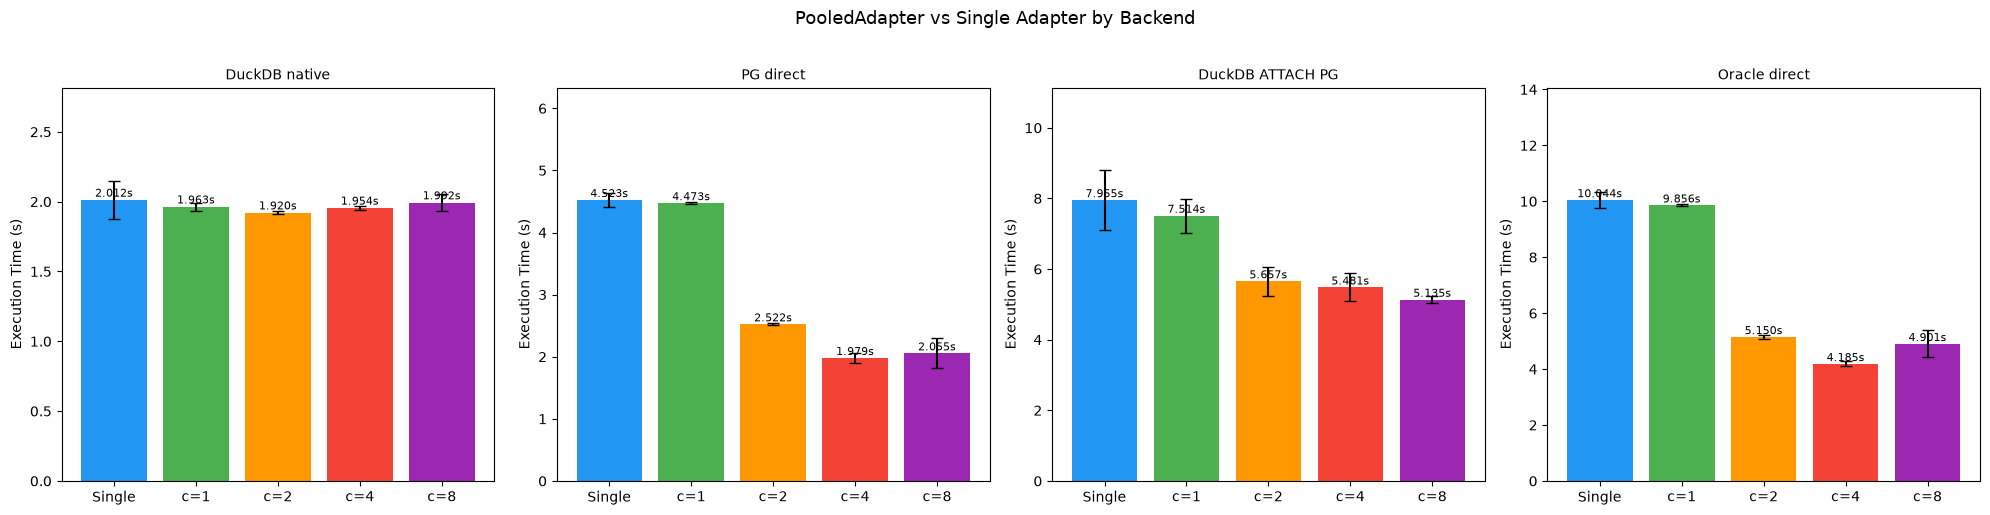

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# --- Single-backend comparison ---
backends = [b for b in backend_names if f"{b} single" in all_results]
n_backends = len(backends)

fig, axes = plt.subplots(1, n_backends, figsize=(5 * n_backends, 5), squeeze=False)

for idx, backend in enumerate(backends):
    ax = axes[0, idx]
    labels = ["Single"] + [f"c={c}" for c in CONCURRENCY_LEVELS]
    means = [statistics.mean(all_results[f"{backend} single"])]
    stds = [statistics.stdev(all_results[f"{backend} single"]) if len(all_results[f"{backend} single"]) > 1 else 0]

    for c in CONCURRENCY_LEVELS:
        key = f"{backend} pooled(c={c})"
        means.append(statistics.mean(all_results[key]))
        stds.append(statistics.stdev(all_results[key]) if len(all_results[key]) > 1 else 0)

    colors = ["#2196F3"] + ["#4CAF50", "#FF9800", "#F44336", "#9C27B0"][:len(CONCURRENCY_LEVELS)]
    bars = ax.bar(labels, means, yerr=stds, capsize=4, color=colors)
    ax.set_ylabel("Execution Time (s)")
    ax.set_title(f"{backend}", fontsize=10)
    ax.set_ylim(0, max(means) * 1.4)

    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{mean:.3f}s", ha="center", va="bottom", fontsize=8)

plt.suptitle("PooledAdapter vs Single Adapter by Backend", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("benchmark_all_backends.png", dpi=150, bbox_inches="tight")
plt.show()

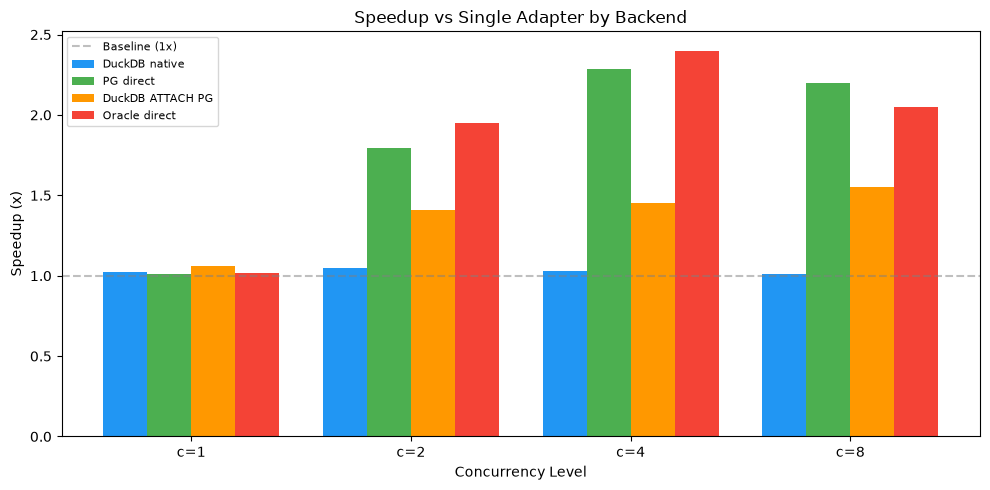

In [26]:
# --- Speedup comparison across all backends ---
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(CONCURRENCY_LEVELS))
width = 0.8 / n_backends
backend_colors = ["#2196F3", "#4CAF50", "#FF9800", "#F44336", "#9C27B0"]

for idx, backend in enumerate(backends):
    baseline = statistics.mean(all_results[f"{backend} single"])
    speedups = []
    for c in CONCURRENCY_LEVELS:
        key = f"{backend} pooled(c={c})"
        speedups.append(baseline / statistics.mean(all_results[key]))

    offset = (idx - n_backends / 2 + 0.5) * width
    ax.bar(x + offset, speedups, width, label=backend, color=backend_colors[idx % len(backend_colors)])

ax.set_xlabel("Concurrency Level")
ax.set_ylabel("Speedup (x)")
ax.set_title("Speedup vs Single Adapter by Backend")
ax.set_xticks(x)
ax.set_xticklabels([f"c={c}" for c in CONCURRENCY_LEVELS])
ax.axhline(y=1, color="gray", linestyle="--", alpha=0.5, label="Baseline (1x)")
ax.legend(fontsize=8)
ax.set_ylim(0)

plt.tight_layout()
plt.savefig("speedup_all_backends.png", dpi=150, bbox_inches="tight")
plt.show()

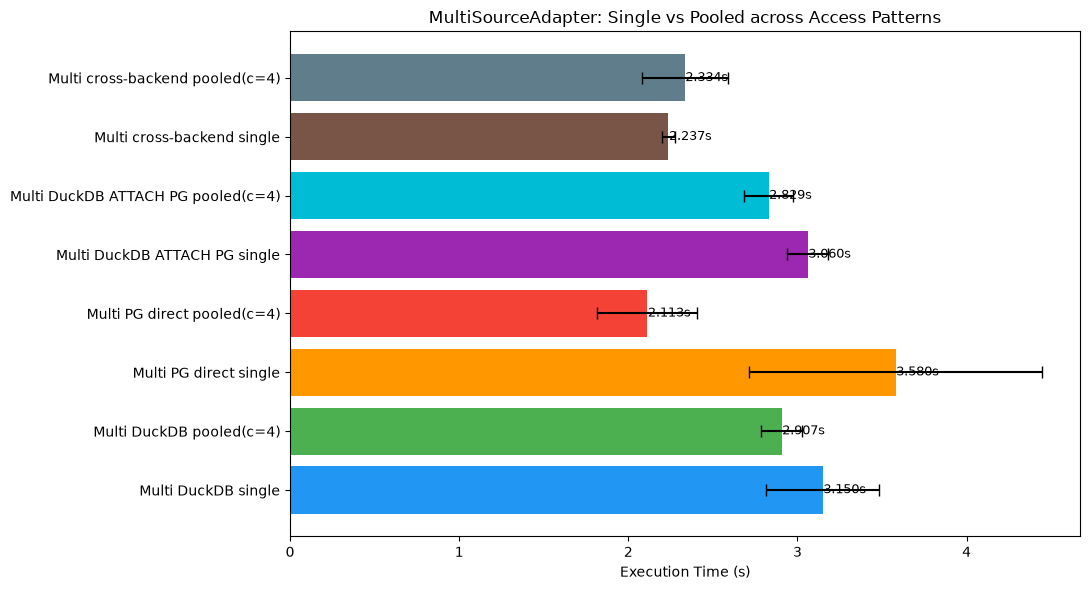

In [27]:
# --- MultiSourceAdapter comparison ---
fig, ax = plt.subplots(figsize=(11, 6))

multi_labels = list(multi_results.keys())
multi_means = [statistics.mean(t) for t in multi_results.values()]
multi_stds = [statistics.stdev(t) if len(t) > 1 else 0 for t in multi_results.values()]

colors = ["#2196F3", "#4CAF50", "#FF9800", "#F44336", "#9C27B0", "#00BCD4", "#795548", "#607D8B"]
bars = ax.barh(multi_labels, multi_means, xerr=multi_stds, capsize=4,
               color=colors[:len(multi_labels)])
ax.set_xlabel("Execution Time (s)")
ax.set_title("MultiSourceAdapter: Single vs Pooled across Access Patterns")

for bar, mean in zip(bars, multi_means):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
            f"{mean:.3f}s", ha="left", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("benchmark_multi_source.png", dpi=150, bbox_inches="tight")
plt.show()

## Scaling: More Checks (5x Duplication)

In [28]:
many_check_refs = hdb_check_refs * 5
print(f"Running {len(many_check_refs)} checks (5x duplication)\n")

scaling_results = {}

for backend in backends:
    if backend == "DuckDB native":
        baseline_adapter = IbisAdapter(con=ibis.duckdb.connect(DUCKDB_PATH))
        factory_fn = duckdb_factory
    elif backend == "PG direct":
        baseline_adapter = IbisAdapter(con=ibis.postgres.connect(**pg_kwargs))
        factory_fn = pg_factory
    elif backend == "DuckDB ATTACH PG":
        baseline_adapter = make_duckdb_attach_pg()
        factory_fn = make_duckdb_attach_pg
    elif backend == "Oracle direct" and oracle_kwargs:
        baseline_adapter = IbisAdapter(con=ibis.oracle.connect(**oracle_kwargs))
        factory_fn = oracle_factory
    else:
        continue

    start = time.perf_counter()
    baseline_adapter.run_checks(many_check_refs)
    single_time = time.perf_counter() - start

    pooled = PooledAdapter(factory=factory_fn, max_concurrency=4)
    start = time.perf_counter()
    pooled.run_checks(many_check_refs)
    pooled_time = time.perf_counter() - start
    pooled.cleanup()

    scaling_results[backend] = {"single": single_time, "pooled_4": pooled_time}
    print(f"{backend}:")
    print(f"  Single:     {single_time:.4f}s")
    print(f"  Pooled(4):  {pooled_time:.4f}s")
    print(f"  Speedup:    {single_time / pooled_time:.2f}x\n")

Running 315 checks (5x duplication)

DuckDB native:
  Single:     14.3490s
  Pooled(4):  11.9946s
  Speedup:    1.20x

PG direct:
  Single:     26.0219s
  Pooled(4):  10.3827s
  Speedup:    2.51x

DuckDB ATTACH PG:
  Single:     40.8961s
  Pooled(4):  32.0798s
  Speedup:    1.27x

Oracle direct:
  Single:     52.2191s
  Pooled(4):  22.9821s
  Speedup:    2.27x



## Concurrency Scaling Curve

  DuckDB native c= 1: 15.0573s
  DuckDB native c= 2: 12.4158s
  DuckDB native c= 4: 13.1671s
  DuckDB native c= 6: 12.5123s
  DuckDB native c= 8: 13.6037s
  DuckDB native c=10: 12.4803s
  DuckDB native c=12: 12.1987s

  PG direct c= 1: 23.7571s
  PG direct c= 2: 13.6744s
  PG direct c= 4: 10.9897s
  PG direct c= 6: 10.6404s
  PG direct c= 8: 10.4950s
  PG direct c=10: 10.6554s
  PG direct c=12: 11.0901s

  DuckDB ATTACH PG c= 1: 39.1454s
  DuckDB ATTACH PG c= 2: 27.9936s
  DuckDB ATTACH PG c= 4: 26.4662s
  DuckDB ATTACH PG c= 6: 26.6034s
  DuckDB ATTACH PG c= 8: 26.4595s
  DuckDB ATTACH PG c=10: 26.7355s
  DuckDB ATTACH PG c=12: 27.7173s

  Oracle direct c= 1: 51.9174s
  Oracle direct c= 2: 25.9693s
  Oracle direct c= 4: 20.5187s
  Oracle direct c= 6: 22.2552s
  Oracle direct c= 8: 22.6963s
  Oracle direct c=10: 22.7017s
  Oracle direct c=12: 22.9158s



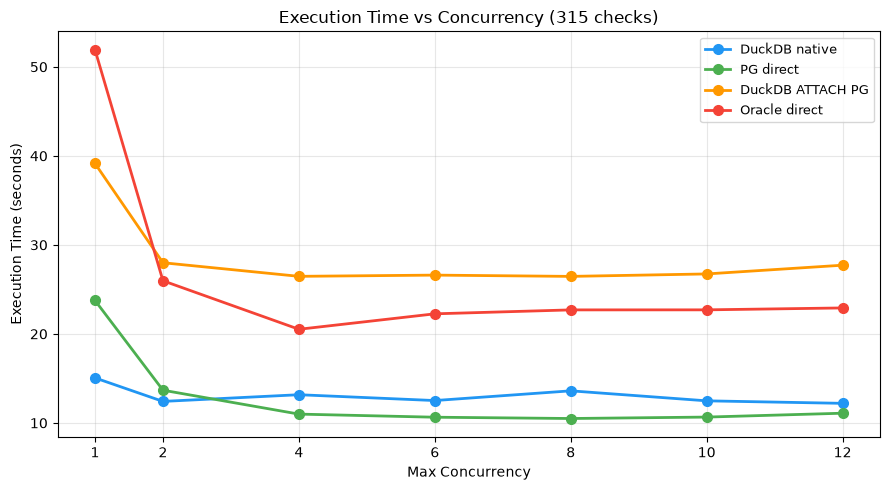

In [29]:
concurrency_sweep = [1, 2, 4, 6, 8, 10, 12]
scaling_curves = {}

for backend in backends:
    if backend == "DuckDB native":
        factory_fn = duckdb_factory
    elif backend == "PG direct":
        factory_fn = pg_factory
    elif backend == "DuckDB ATTACH PG":
        factory_fn = make_duckdb_attach_pg
    elif backend == "Oracle direct" and oracle_kwargs:
        factory_fn = oracle_factory
    else:
        continue

    times = []
    for c in concurrency_sweep:
        pooled = PooledAdapter(factory=factory_fn, max_concurrency=c)
        start = time.perf_counter()
        pooled.run_checks(many_check_refs)
        elapsed = time.perf_counter() - start
        times.append(elapsed)
        pooled.cleanup()
        print(f"  {backend} c={c:2d}: {elapsed:.4f}s")

    scaling_curves[backend] = times
    print()

fig, ax = plt.subplots(figsize=(9, 5))
curve_colors = {
    "DuckDB native": "#2196F3",
    "PG direct": "#4CAF50",
    "DuckDB ATTACH PG": "#FF9800",
    "Oracle direct": "#F44336",
    "DuckDB ATTACH Oracle": "#9C27B0",
}

for backend, times in scaling_curves.items():
    ax.plot(concurrency_sweep, times, "o-", color=curve_colors.get(backend, "gray"),
            linewidth=2, markersize=7, label=backend)

ax.set_xlabel("Max Concurrency")
ax.set_ylabel("Execution Time (seconds)")
ax.set_title(f"Execution Time vs Concurrency ({len(many_check_refs)} checks)")
ax.set_xticks(concurrency_sweep)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("scaling_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## Cleanup

In [30]:
Path(DUCKDB_PATH).unlink(missing_ok=True)
Path(DUCKDB_EMP_PATH).unlink(missing_ok=True)
Path(DUCKDB_LIST_PATH).unlink(missing_ok=True)

try:
    pg_container.stop()
    print("PostgreSQL container stopped")
except Exception:
    pass
if oracle_container:
    try:
        oracle_container.stop()
        print("Oracle container stopped")
    except Exception:
        pass

print("Cleanup complete")

PostgreSQL container stopped
Oracle container stopped
Cleanup complete


## Observations

### Access Pattern Comparison

| Pattern | Description | Expected Pooling Benefit |
|---------|-------------|------------------------|
| DuckDB native | Data in-process | Minimal — no I/O wait to overlap |
| PG direct | ibis.postgres.connect | Moderate — network round-trips overlap |
| DuckDB ATTACH PG | DuckDB engine → PG scanner | Interesting — DuckDB optimizes but still has network I/O |
| Oracle direct | ibis.oracle.connect | High — heaviest per-query overhead |
| DuckDB ATTACH Oracle | DuckDB engine → Oracle scanner | Depends on scanner efficiency |

### Key Findings

1. **DuckDB ATTACH vs Direct** — ATTACH routes queries through DuckDB's optimizer which may
   batch/pipeline differently. Compare baseline times (single adapter) to see if ATTACH
   is faster or slower than direct connections for individual checks.

2. **Pooling + ATTACH** — Each pooled ATTACH connection is an independent DuckDB process
   with its own attached scanner. This tests whether DuckDB's scanner handles concurrent
   access to the same remote database.

3. **MultiSource ATTACH** — Using ATTACH for cross-table checks avoids Mode 2
   materialization (export → local DuckDB) since DuckDB can query across schemas
   within its own engine.